In [1]:
!pip install scikit-learn matplotlib numpy pandas plotly

In [2]:
!pip install --upgrade nbformat

Combinazione di Supervised & Unsupervised

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

In [4]:
data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [6]:
X, y = data.data, data.target
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.dtypes

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

1. Regressione lineare base. Possiamo farla perché i dati sono continui.

In [ ]:
# creazione del modello, addestramento dei dati e predizione delle y

model_base = LinearRegression()
model_base.fit(X, y)
y_pred_base = model_base.predict(X)

# verifica degli errori e calcolo del MAE
errors_base = np.abs(y - y_pred_base)
mae_base = np.mean(errors_base)

print(f"Predizioni del modello base: {y_pred_base}")
print (f"Errori del modello base: {errors_base}")
print("MAE del modello base:", mae_base)

Predizioni del modello base: [206.11667725  68.07103297 176.88279035 166.91445843 128.46225834
 106.35191443  73.89134662 118.85423042 158.80889721 213.58462442
  97.07481511  95.10108423 115.06915952 164.67656842 103.07814257
 177.17487964 211.7570922  182.84134823 148.00326937 124.01754066
 120.33362197  85.80068961 113.1134589  252.45225837 165.48779206
 147.71997564  97.12871541 179.09358468 129.05345958 184.7811403
 158.71516713  69.47575778 261.50385365 112.82234716  78.37318279
  87.66360785 207.92114668 157.87641942 240.84708073 136.93257456
 153.48044608  74.15426666 145.62742227  77.82978811 221.07832768
 125.21957584 142.6029986  109.49562511  73.14181818 189.87117754
 157.9350104  169.55699526 134.1851441  157.72539008 139.11104979
  72.73116856 207.82676612  80.11171342 104.08335958 134.57871054
 114.23552012 180.67628279  61.12935368  98.72404613 113.79577026
 189.95771575 148.98351571 124.34152283 114.8395504  121.99957578
  73.91017087 236.71054289 142.31126791 124.5167

2. Regressione lineare (clustering)

In [ ]:
# il parametro random_state è usato per garantire la riproducibilità dei risultati, in quanto KMeans utilizza un processo di inizializzazione casuale ma uguale per ogni esecuzione 
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

#c_ serve per concatenare ciò che sta fra quadre
X_new = np.c_[X, clusters]

model_clustering = LinearRegression()
model_clustering.fit(X_new, y)

y_pred_clustering = model_clustering.predict(X_new)

errors_clustering = np.abs(y - y_pred_clustering)
mae_clustering = np.mean(errors_clustering)

print(f"Predizioni del modello con clustering: {y_pred_clustering}")
print(f"Errori del modello con clustering: {errors_clustering}")
print("MAE del modello con clustering:", mae_clustering)

Predizioni del modello con clustering: [206.68295498  65.61230411 175.65147322 144.7642444  139.27949169
 109.27460794  85.38310227 123.78868304 153.33673739 196.13467462
 104.72675468  75.45386039 124.04125869 155.18502283 108.5576239
 178.17764647 195.11991569 197.97473192 160.40861347 131.73319409
 130.12223682  94.57294828 117.64653807 256.48509172 175.34595654
 133.80892982 100.29208186 163.00464834 145.21933206 181.74380243
 169.82413001  71.19483518 262.66159475 117.62463007  84.13367714
  96.32880653 195.05727534 170.11761073 251.05455041 124.81700413
 161.57165105  71.24464395 133.4980393   79.21510388 219.69086518
 114.72381755 152.61912643 116.83573834  56.92314359 179.80456826
 145.77834204 166.68153183 141.13225483 140.08699536 146.94106065
  68.11874128 194.00972579  81.60106318 103.62893391 140.3581344
 117.80409475 168.90392568  65.11227938 105.34507445 105.04844374
 195.55785436 137.19460929 114.66662234 102.37011429 136.34646732
  74.78927112 247.73636867 142.01671853

3. Errors plot

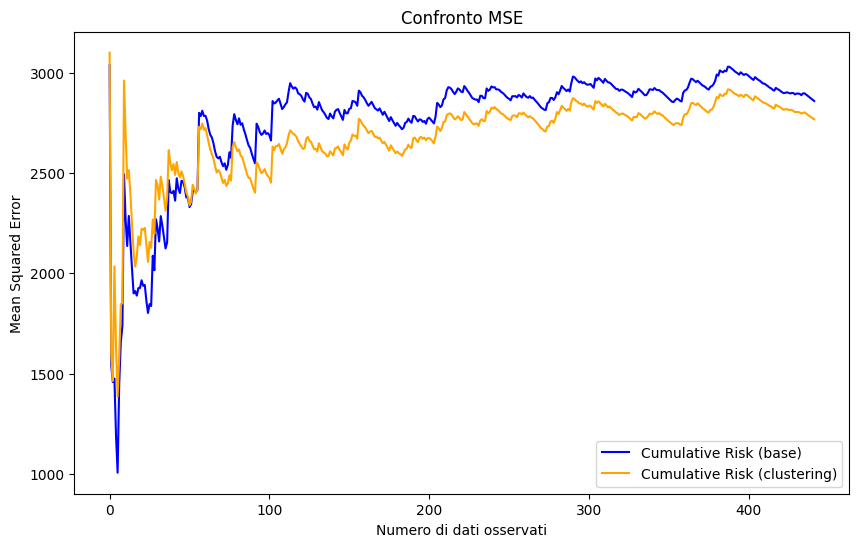

In [ ]:
cumulative_base = np.cumsum((y - y_pred_base) **2) / (np.arange(1, len(y) + 1))
cumulative_clustering = np.cumsum((y - y_pred_clustering) **2) / (np.arange(1, len(y) + 1))

plt.figure(figsize=(10, 6))
plt.plot(cumulative_base, label='Cumulative Risk (base)', color='blue')
plt.plot(cumulative_clustering, label='Cumulative Risk (clustering)', color='orange')
plt.xlabel('Numero di dati osservati')
plt.ylabel('Mean Squared Error')
plt.title("Confronto MSE")
plt.legend()
plt.show()

# dall'analisi del grafico si evince che il modello con il clustering inizialmente genera un errore maggiore rispetto al modello base, 
# ma con l'aumentare del numero di dati osservati, il modello con il clustering mostra un miglioramento significativo, superando il modello base in termini di MSE
# in quanto la riga arancione è sempre al di sotto di quella blu

4. Linear regression Plot

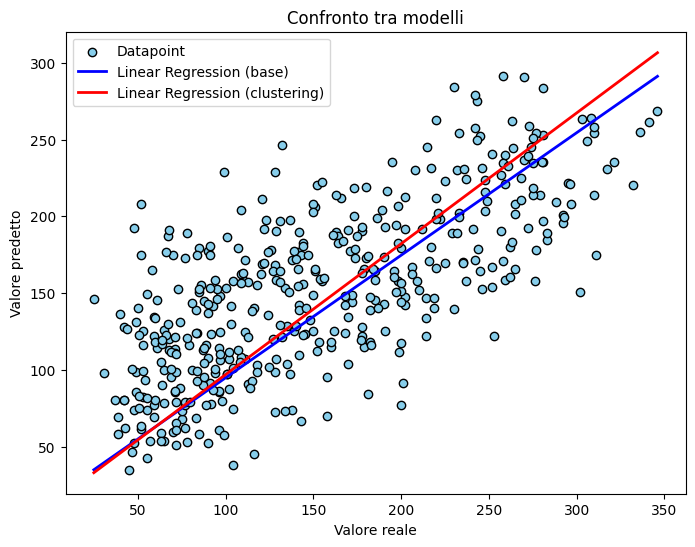

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(y, y_pred_base, color="skyblue", edgecolors="black", label="Datapoint")
plt.plot([y.min(), y.max()], [y_pred_base.min(), y_pred_base.max()], color="blue", linewidth=2, label="Linear Regression (base)")
plt.plot([y.min(), y.max()], [y_pred_clustering.min(), y_pred_clustering.max()], color="red", linewidth=2, label="Linear Regression (clustering)")

plt.xlabel("Valore reale")
plt.ylabel("Valore predetto")
plt.title("Confronto tra modelli")
plt.legend()
plt.show()